# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Ahmad Fajar Permadi
- **Email:** ahmadfajarpermadi@gmail.com
- **ID Dicoding:** ahmadfajar_permadi

## Menentukan Pertanyaan Bisnis

Dataset yang digunakan adalah Beijing Air Quality Dataset yang berisi data kualitas udara dari berbagai stasiun pemantauan di Beijing pada tahun 2013–2017. Dataset ini mencakup berbagai parameter polusi udara seperti PM2.5, PM10, SO2, NO2, CO, dan O3 serta faktor meteorologi seperti suhu, tekanan udara, curah hujan, dan kecepatan angin.

Pertanyaan bisnis yang ingin dijawab melalui analisis data ini adalah:

1. Bagaimana pola perubahan konsentrasi PM2.5 pada setiap bulan dan musim di berbagai stasiun pemantauan udara dari tahun 2013–2017, dan pada periode waktu mana tingkat polusi paling tinggi terjadi?

2. Bagaimana hubungan antara faktor meteorologi seperti suhu, kecepatan angin, curah hujan, dan tekanan udara dengan perubahan konsentrasi PM2.5 selama periode 2013–2017?

3. Analisis geospasial menunjukkan bahwa distribusi polusi udara di Beijing tidak merata, sehingga diperlukan perhatian khusus pada wilayah dengan tingkat polusi lebih tinggi.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

sns.set(style="whitegrid")

## Data Wrangling

### Gathering Data

In [2]:
import glob

path = "data/*.csv"
files = glob.glob(path)

df_list = []

for file in files:
    data = pd.read_csv(file)
    df_list.append(data)

df = pd.concat(df_list, ignore_index=True)

df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**

- Dataset terdiri dari beberapa file yang merepresentasikan stasiun pemantauan kualitas udara yang berbeda.
- Setelah digabungkan, dataset berisi informasi waktu, lokasi stasiun, berbagai jenis polutan udara, serta faktor meteorologi.

### Assessing Data

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

**Insight:**

- Terdapat beberapa nilai kosong pada variabel polutan seperti PM2.5 dan PM10.
- Dataset memiliki data time series yang mencakup tahun 2013 hingga 2017.

### Cleaning Data

In [4]:
df = df.dropna()

df["datetime"] = pd.to_datetime(
    df[["year","month","day","hour"]]
)

df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


**Insight:**

- Nilai kosong dihapus agar analisis tidak bias.
- Kolom waktu digabung menjadi satu kolom datetime untuk mempermudah analisis time series.

### Menyimpan Data Gabungan

In [5]:
df.to_csv("dashboard/main_data.csv", index=False)

## Exploratory Data Analysis (EDA)

In [6]:
df.groupby("station")["PM2.5"].mean().sort_values(ascending=False)

station
Dongsi           84.933156
Nongzhanguan     84.720783
Wanshouxigong    84.238510
Gucheng          83.865653
Guanyuan         83.101051
Wanliu           81.981459
Aotizhongxin     81.863630
Tiantan          81.749840
Shunyi           79.400725
Changping        70.312328
Huairou          70.285669
Dingling         66.512518
Name: PM2.5, dtype: float64

##### Distribusi PM2.5:

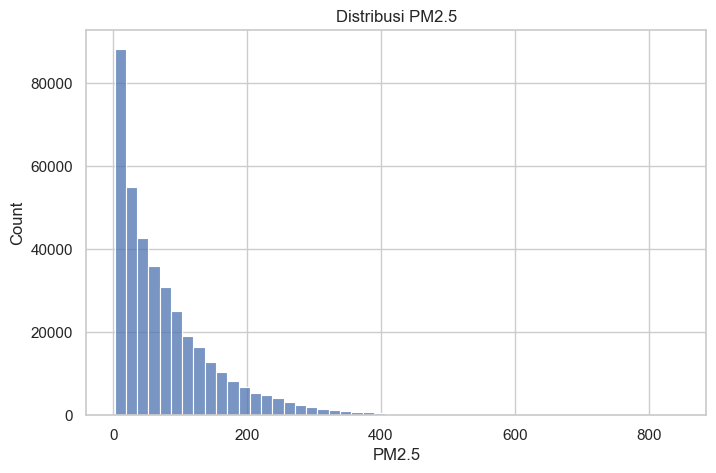

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["PM2.5"], bins=50)
plt.title("Distribusi PM2.5")
plt.show()

**Insight:**

- Distribusi PM2.5 menunjukkan adanya nilai yang cukup tinggi pada beberapa periode tertentu.
- Hal ini mengindikasikan adanya periode polusi udara yang signifikan di Beijing.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

#### Pola PM2.5 per Bulan

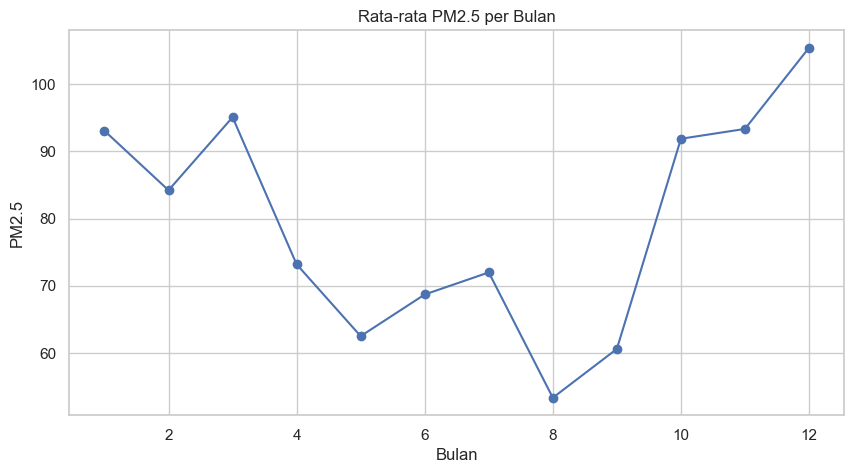

In [8]:
monthly_pm25 = df.groupby("month")["PM2.5"].mean()

plt.figure(figsize=(10,5))
monthly_pm25.plot(kind="line", marker="o")

plt.title("Rata-rata PM2.5 per Bulan")
plt.xlabel("Bulan")
plt.ylabel("PM2.5")
plt.show()

**Insight:**
- Polusi udara PM2.5 cenderung meningkat pada musim dingin. Hal ini kemungkinan disebabkan oleh penggunaan bahan bakar untuk pemanas serta kondisi atmosfer yang menyebabkan polutan terperangkap di udara.

### Pertanyaan 2:

#### Korelasi Cuaca dan PM2.5

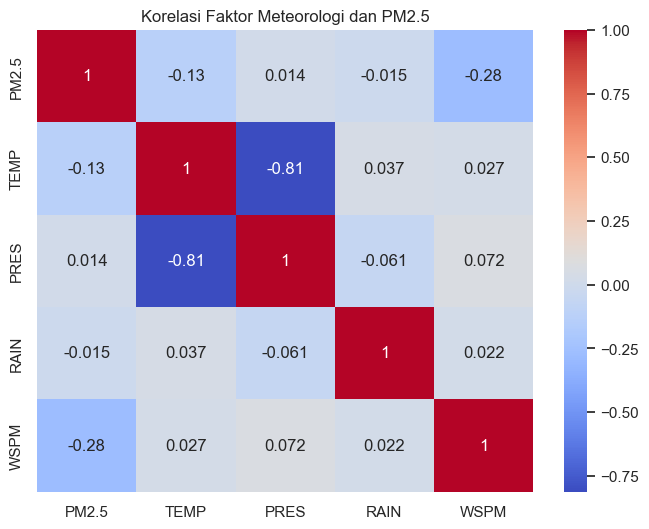

In [9]:
corr = df[["PM2.5","TEMP","PRES","RAIN","WSPM"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Korelasi Faktor Meteorologi dan PM2.5")
plt.show()

**Insight:**
- Kecepatan angin menunjukkan korelasi negatif terhadap PM2.5, yang berarti semakin tinggi kecepatan angin maka konsentrasi polusi udara cenderung menurun.

## Analisis Lanjutan (Opsional)

### Manual Clustering

In [10]:
def kategori_polusi(pm):
    if pm <= 50:
        return "Rendah"
    elif pm <= 100:
        return "Sedang"
    elif pm <= 150:
        return "Tinggi"
    else:
        return "Sangat Tinggi"

df["kategori_polusi"] = df["PM2.5"].apply(kategori_polusi)

df["kategori_polusi"].value_counts()

kategori_polusi
Rendah           181364
Sedang            92628
Sangat Tinggi     57807
Tinggi            50369
Name: count, dtype: int64

##### Visualisasi

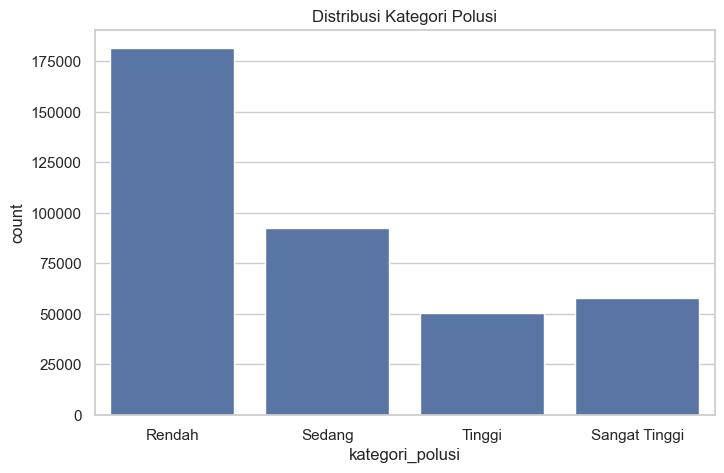

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="kategori_polusi")

plt.title("Distribusi Kategori Polusi")
plt.show()

- Clustering dilakukan dengan metode **manual grouping** berdasarkan standar kualitas udara PM2.5. Data dikelompokkan menjadi empat kategori yaitu rendah, sedang, tinggi, dan sangat tinggi untuk memahami distribusi tingkat polusi udara.

### Geospatial Analysis

Analisis geospasial dilakukan untuk memahami distribusi tingkat polusi udara berdasarkan lokasi geografis stasiun pemantauan. Dengan menggunakan visualisasi peta, kita dapat mengidentifikasi wilayah dengan konsentrasi polusi udara yang lebih tinggi dibandingkan wilayah lainnya.

Dalam analisis ini digunakan library **Folium** untuk menampilkan peta interaktif yang menunjukkan rata-rata konsentrasi PM2.5 pada setiap stasiun pemantauan.

In [12]:
# Mapping Manual.

station_location = {
    "Aotizhongxin": (39.982,116.397),
    "Changping": (40.217,116.231),
    "Dingling": (40.292,116.220),
    "Dongsi": (39.929,116.417),
    "Guanyuan": (39.933,116.339),
    "Gucheng": (39.914,116.184),
    "Huairou": (40.357,116.631),
    "Nongzhanguan": (39.937,116.461),
    "Shunyi": (40.127,116.655),
    "Tiantan": (39.886,116.407),
    "Wanliu": (39.987,116.298),
    "Wanshouxigong": (39.878,116.352)
}

In [13]:
# Hitung Rata-rata PM2.5 per Stasiun

pm25_station = df.groupby("station")["PM2.5"].mean().reset_index()
pm25_station

,station,PM2.5
0,Aotizhongxin,81.863630
1,Changping,70.312328
2,Dingling,66.512518
3,Dongsi,84.933156
4,Guanyuan,83.101051
5,Gucheng,83.865653
6,Huairou,70.285669
7,Nongzhanguan,84.720783
8,Shunyi,79.400725
9,Tiantan,81.749840


In [14]:
# Color Gradient

min_pm25 = pm25_station["PM2.5"].min()
max_pm25 = pm25_station["PM2.5"].max()

def get_color(pm25):
    
    ratio = (pm25 - min_pm25) / (max_pm25 - min_pm25)
    
    r = 255
    g = int(255 * (1 - ratio))
    b = 0
    
    return f'#{r:02x}{g:02x}{b:02x}'

In [15]:
# Membuat Peta

map_beijing = folium.Map(location=[39.9042,116.4074], zoom_start=10)

for index, row in pm25_station.iterrows():
    
    station = row["station"]
    pm25 = row["PM2.5"]
    
    lat, lon = station_location[station]
    
    color = get_color(pm25)
    
    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        popup=f"{station} - PM2.5: {pm25:.2f}",
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8
    ).add_to(map_beijing)

map_beijing

### Insight

Berdasarkan visualisasi peta, terlihat bahwa beberapa stasiun memiliki rata-rata konsentrasi PM2.5 yang lebih tinggi dibandingkan stasiun lainnya. Hal ini menunjukkan bahwa distribusi polusi udara di Beijing tidak merata dan terdapat wilayah tertentu yang memiliki tingkat polusi lebih tinggi.

Informasi ini dapat digunakan oleh pemerintah atau pengambil kebijakan untuk menentukan prioritas wilayah dalam upaya pengendalian polusi udara.

### Analisis Pola Polusi Berdasarkan Jam

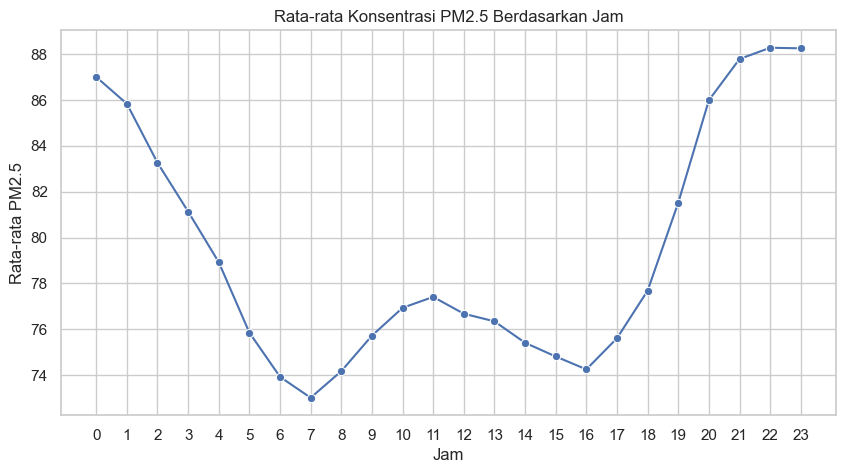

In [16]:
pm25_hourly = df.groupby("hour")["PM2.5"].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=pm25_hourly.index,
    y=pm25_hourly.values,
    marker="o"
)

plt.title("Rata-rata Konsentrasi PM2.5 Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Rata-rata PM2.5")
plt.xticks(range(0,24))

plt.show()

#### Insight

Berdasarkan visualisasi, terlihat bahwa konsentrasi PM2.5 cenderung meningkat pada jam-jam tertentu dalam sehari. Pola ini kemungkinan berkaitan dengan aktivitas manusia seperti peningkatan lalu lintas kendaraan pada jam sibuk serta aktivitas industri pada siang hari.

### Analisis PM2.5 Berdasarkan Musim

In [17]:
def get_season(month):
    
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

In [18]:
## Hitung rata-rata PM2.5 per musim

pm25_season = df.groupby("season")["PM2.5"].mean()

pm25_season

season
Autumn    82.007421
Spring    77.251301
Summer    64.448162
Winter    94.377216
Name: PM2.5, dtype: float64

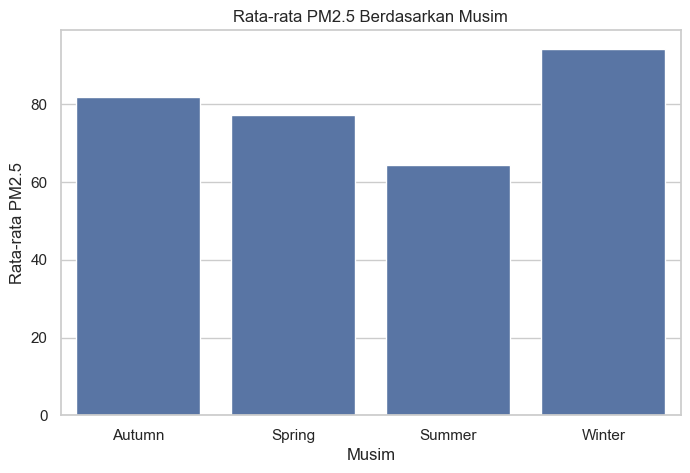

In [19]:
## Visualisasi

plt.figure(figsize=(8,5))

sns.barplot(
    x=pm25_season.index,
    y=pm25_season.values
)

plt.title("Rata-rata PM2.5 Berdasarkan Musim")
plt.xlabel("Musim")
plt.ylabel("Rata-rata PM2.5")

plt.show()

#### Insight

Hasil analisis menunjukkan bahwa tingkat polusi udara cenderung lebih tinggi pada musim dingin dibandingkan musim lainnya. Hal ini dapat disebabkan oleh peningkatan penggunaan bahan bakar untuk pemanas serta kondisi atmosfer yang menyebabkan polutan terperangkap di udara.

## Conclusion

### Pertanyaan 1
Polusi udara PM2.5 menunjukkan pola musiman dengan tingkat polusi tertinggi terjadi pada bulan-bulan musim dingin. Hal ini menunjukkan bahwa faktor musiman memiliki pengaruh terhadap kualitas udara di Beijing.

### Pertanyaan 2
Faktor meteorologi seperti kecepatan angin memiliki hubungan dengan konsentrasi PM2.5. Kecepatan angin yang lebih tinggi cenderung membantu menyebarkan polutan sehingga menurunkan konsentrasi polusi udara.

### Pertanyaan 3
Analisis geospasial menunjukkan bahwa distribusi polusi udara di Beijing tidak merata, sehingga diperlukan perhatian khusus pada wilayah dengan tingkat polusi lebih tinggi.